# Nhiệm vụ 4: Supervised Learning - Classification Pipeline
Dự đoán `Cluster_Label` bằng Logistic Regression và Decision Tree.

## 0. Import thư viện

In [1]:
%pip install pandas matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Student\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd                             
import matplotlib.pyplot as plt                    
import seaborn as sns                                
from sklearn.model_selection import train_test_split   
from sklearn.preprocessing import StandardScaler       
from sklearn.linear_model import LogisticRegression   
from sklearn.tree import DecisionTreeClassifier   
from sklearn.metrics import classification_report, confusion_matrix  
import joblib                                       

## 1. Đọc dữ liệu & chọn biến
Chọn `Cluster_Label` làm biến mục tiêu (y), các cột số/đã mã hóa làm đặc trưng (X).

In [3]:
df = pd.read_csv("master_dataset_with_cluster_labels.csv") 

TARGET = "Cluster_Label"  
y = df[TARGET]             


features = ["Age", "UnitPrice", "Quantity", "TotalAmount", "Price", "Rating",
            "Gender_Nữ", "PaymentMethod_Thẻ ngân hàng",
            "PaymentMethod_Tiền mặt", "PaymentMethod_Ví điện tử"]
X = df[features].astype(float)  # đổi True/False thành 1.0/0.0

# Lưu ý: nếu chọn TARGET = "PaymentMethod" thì phải bỏ 3 cột PaymentMethod_... khỏi features

## 2. Chia tập train / test (80/20)
Chuẩn hóa dữ liệu bằng `StandardScaler` để Logistic Regression hội tụ tốt.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)  

scaler = StandardScaler()                    
X_train = scaler.fit_transform(X_train)      
X_test = scaler.transform(X_test)          

## 3. Khai báo 2 mô hình
Logistic Regression và Decision Tree.

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

## 4. Huấn luyện, đánh giá & vẽ Confusion Matrix
In `classification_report` và vẽ heatmap cho từng mô hình.


===== name =====
              precision    recall  f1-score   support

           0       0.52      0.94      0.67        51
           1       0.00      0.00      0.00         9
           2       0.51      0.65      0.57        31
           3       0.63      1.00      0.77        43
           4       0.00      0.00      0.00        26
           5       0.00      0.00      0.00        15
           6       0.00      0.00      0.00        15
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1

    accuracy                           0.56       200
   macro avg       0.17      0.26      0.20       200
weighted avg       0.35      0.56      0.43       200


===== name =====
              precision    recall  f1-score   support

           0       0.69      0.73      0.70        51
           1       0.38      0.67      0.48         9
           2       0.56      0.58      0.5

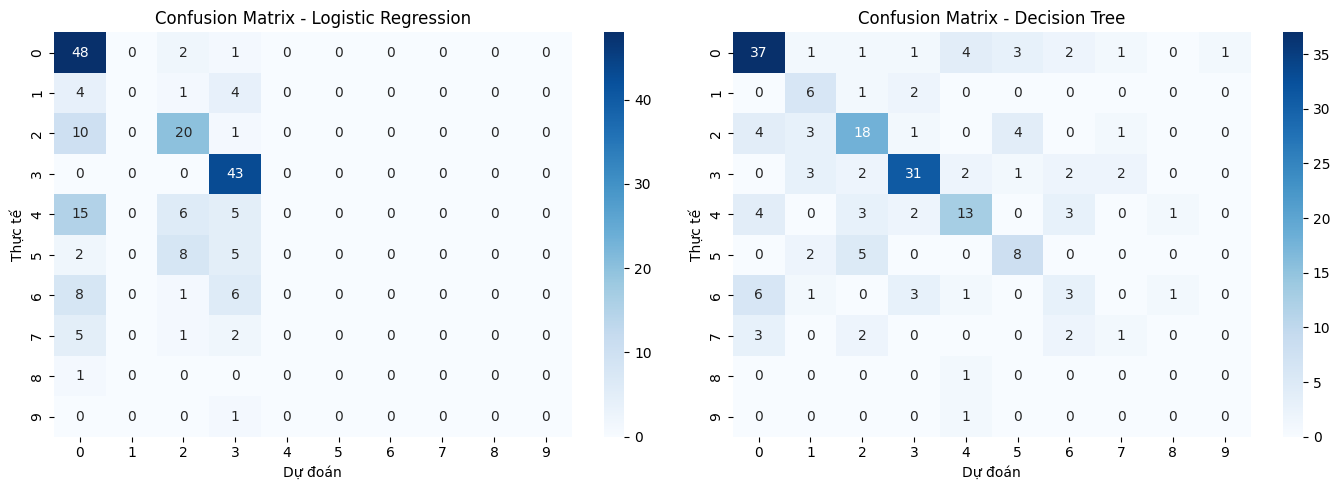

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)                 
    joblib.dump(model, f"model_{name.replace(' ', '_')}.joblib")  
    y_pred = model.predict(X_test)            

    print(f"\n===== name =====")
    print(classification_report(y_test, y_pred, zero_division=0))  

    cm = confusion_matrix(y_test, y_pred)   
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax) 
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Dự đoán")                   
    ax.set_ylabel("Thực tế")                

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)    
plt.show()                                      

## 5. Lưu model & ví dụ nạp lại
Lưu cả `scaler` vì model được huấn luyện trên dữ liệu đã chuẩn hóa.

In [7]:
joblib.dump(scaler, "scaler.joblib")          
print("\nĐã lưu: model_Logistic_Regression.joblib, model_Decision_Tree.joblib, scaler.joblib")

model_loaded = joblib.load("model_Decision_Tree.joblib")  
scaler_loaded = joblib.load("scaler.joblib")             
sample = scaler_loaded.transform(X.iloc[:5])               
print("Dự đoán 5 dòng đầu:", model_loaded.predict(sample))
print("Nhãn thật         :", y.iloc[:5].tolist())        


Đã lưu: model_Logistic_Regression.joblib, model_Decision_Tree.joblib, scaler.joblib
Dự đoán 5 dòng đầu: [2 3 2 3 2]
Nhãn thật         : [2, 3, 2, 3, 2]


## 6. Nhận xét kết quả
- **Accuracy** hai mô hình gần nhau (~0.56 và ~0.58), nhưng **F1 macro** của Decision Tree (~0.39) cao hơn hẳn Logistic Regression (~0.20).
- **Logistic Regression** chỉ đoán đúng các nhóm lớn (0, 2, 3), hầu như không nhận ra các nhóm còn lại vì chỉ vẽ ranh giới thẳng.
- **Decision Tree** chia dữ liệu bằng nhiều điều kiện "nếu... thì..." nên nhận ra được nhiều nhóm hơn, kể cả nhóm nhỏ.
- **Hạn chế:** dữ liệu mất cân bằng (nhóm 8, 9 chỉ có rất ít mẫu) nên cả hai mô hình đều kém ở các nhóm này.
- **Kết luận:** Decision Tree phù hợp hơn cho bài toán này.